# 09 — LangGraph: you draw the arrows

Module 08 hid the wiring inside `Runner`, `as_tool`, and `handoffs`. `draw_graph` showed you what the SDK had already decided.

LangGraph is the other way around. **You write the nodes and the edges.** The picture is not a visualisation of a product. It is the program.

Same shop. Same named tools. Same Helena question: **7** invoices, **$49.62**, rep **Steve Johnson**. The comparison with 08 is one variable: the framework.

What this module adds, that 08 cannot do in one line: **pause the run, look at the state, resume.** That is why a compliance desk picks a graph.

Docs: [docs.langchain.com/oss/python/langgraph](https://docs.langchain.com/oss/python/langgraph).


## 1. Learn

```
08  Agents SDK — three wirings, the SDK owns the arrows
09  you are here — State, Node, Edge. You own the arrows
10  CrewAI — roles and a crew
13  delegation — when the desk is another agent
```

Three words:

| Word | Meaning today |
|---|---|
| **State** | A dict you define. It walks the graph. Each node returns the fields it changed. |
| **Node** | A Python function. `state` in, partial state out. May call a model. May not. |
| **Edge** | Who runs next. Fixed (`add_edge`) or a function of state (`add_conditional_edges`). |

Five steps, every time: define the state, start a builder, add nodes, add edges, compile.

```
START --> chatbot --tool_calls?--> tools --> chatbot --> ...
                    |
                    +-- no --> END
```

That picture is the official loop from module 03. In 08, `Runner` was that loop. Today you can **see the `for`** as two boxes and a condition.

A reducer (`add_messages`) says how a field updates. For chat, new messages **append**. Without it, a node would overwrite the whole list.

Talking points — say these once:

1. A graph is Python functions joined together. The first graph has no model.
2. `tools_condition` is not an LLM. It looks at the last message. If there are `tool_calls`, go to `tools`. Else end. Module 02 again.
3. Draw the mermaid **before** you invoke. Same order as 08.
4. `interrupt` needs a checkpointer and a `thread_id`. Resume with `Command(resume=...)`. That is the enterprise sentence.
5. We are not signing up for LangSmith. The mermaid and `get_state` are Observe.


## 2. Do

### Load the environment and Chinook


In [1]:
from pathlib import Path
import os
import sqlite3
import unicodedata
from typing import Annotated
from typing_extensions import TypedDict

from dotenv import load_dotenv, find_dotenv
from IPython.display import Image, display
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.types import Command, interrupt


def fold(text: str) -> str:
    nfkd = unicodedata.normalize('NFKD', text)
    return ''.join(ch for ch in nfkd if not unicodedata.combining(ch)).casefold()


load_dotenv(find_dotenv(usecwd=True))
ROOT = Path(find_dotenv(usecwd=True)).parent

api_key = os.environ.get('OPENAI_API_KEY', '').strip()
model = os.environ.get('MODEL_DEFAULT', '').strip()
model_strong = os.environ.get('MODEL_STRONG', '').strip() or model
assert api_key, 'OPENAI_API_KEY is missing.'
assert model, 'MODEL_DEFAULT is missing.'

# Frameworks run tools on a worker thread. False is safe: this connection is read-only.
db = sqlite3.connect(ROOT / 'data' / 'chinook.db', check_same_thread=False)
db.row_factory = sqlite3.Row
llm = ChatOpenAI(model=model, reasoning_effort='none')

print('OPENAI_API_KEY is set:', True)
print('MODEL_DEFAULT:', model)
print('customers:', db.execute('select count(*) from customers').fetchone()[0])


OPENAI_API_KEY is set: True
MODEL_DEFAULT: gpt-5.4-nano
customers: 59


`show_graph` tries a PNG (needs `dot` or a mermaid service). If that fails, it prints the mermaid text. You can still read the arrows.


In [2]:
def show_graph(compiled):
    picture = compiled.get_graph()
    try:
        display(Image(picture.draw_mermaid_png()))
    except Exception as exc:
        print('PNG not drawn:', exc)
        print(picture.draw_mermaid())


### Named tools, same as 08

The decorator is now LangChain's `@tool`. Same idea as `@function_tool`: the docstring is the schema. We still prove the functions with no model.


In [3]:
def find_customer(name: str):
    needle = fold(name).strip()
    hits = []
    for row in db.execute(
        'select CustomerId, FirstName, LastName, SupportRepId from customers'
    ):
        full = fold(row['FirstName'] + ' ' + row['LastName'])
        if needle == full or needle == fold(row['FirstName']) or needle in full:
            hits.append(row)
    if len(hits) == 1:
        return hits[0]
    if not hits:
        return None
    return hits[0]


def count_invoices_fn(name: str) -> str:
    row = find_customer(name)
    if row is None:
        return 'no customer by that name'
    n = db.execute(
        'select count(*) from invoices where CustomerId = ?',
        (row['CustomerId'],),
    ).fetchone()[0]
    return f"{row['FirstName']} {row['LastName']} has {n} invoices"


def invoice_total_fn(name: str) -> str:
    row = find_customer(name)
    if row is None:
        return 'no customer by that name'
    total = db.execute(
        'select round(sum(Total), 2) from invoices where CustomerId = ?',
        (row['CustomerId'],),
    ).fetchone()[0]
    return f"{row['FirstName']} {row['LastName']} has spent {total} dollars"


def support_rep_fn(name: str) -> str:
    row = find_customer(name)
    if row is None:
        return 'no customer by that name'
    rep = db.execute(
        'select FirstName || \' \' || LastName from employees where EmployeeId = ?',
        (row['SupportRepId'],),
    ).fetchone()[0]
    return f"{row['FirstName']} {row['LastName']}'s support rep is {rep}"


@tool
def count_invoices(name: str) -> str:
    'How many invoices this customer has.'
    return count_invoices_fn(name)


@tool
def invoice_total(name: str) -> str:
    'Total amount this customer has spent, in dollars.'
    return invoice_total_fn(name)


@tool
def support_rep(name: str) -> str:
    'The support representative for this customer.'
    return support_rep_fn(name)


print(count_invoices_fn('Helena'))
print(invoice_total_fn('Helena Holy'))
print(support_rep_fn('Helena Holý'))
print('schema keys:', list(count_invoices.args_schema.model_json_schema()['properties']))


Helena Holý has 7 invoices
Helena Holý has spent 49.62 dollars
Helena Holý's support rep is Steve Johnson
schema keys: ['name']


7, 49.62, Steve Johnson. No model. `@tool` wrote the JSON from the signature, same truth as 02.

### Part 1 — A graph with no model

State is two fields. One node looks Helena up. No LLM. If this cell is clear, the rest is the same shape with more boxes.

Talking points:

1. `TinyState` is the whole memory of this program.
2. The node returns only what it changed (`fact`). `name` stays.
3. `START` and `END` are not your functions. They are the frame.


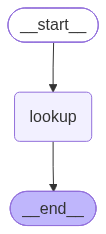

In [4]:
class TinyState(TypedDict):
    name: str
    fact: str


def lookup_node(state: TinyState) -> dict:
    return {'fact': count_invoices_fn(state['name'])}


builder = StateGraph(TinyState)
builder.add_node('lookup', lookup_node)
builder.add_edge(START, 'lookup')
builder.add_edge('lookup', END)
tiny = builder.compile()

show_graph(tiny)


One box. Then run it. The result is a dict, not a `RunResult`.


In [5]:
tiny_out = tiny.invoke({'name': 'Helena', 'fact': ''})
print(tiny_out)


{'name': 'Helena', 'fact': 'Helena Holý has 7 invoices'}


`{'name': 'Helena', 'fact': '...7 invoices'}`. You wrote every arrow.

### Part 2 — The official loop, as a graph

State is now the message list, with `add_messages` so each node **appends**.

Two nodes:

- `chatbot` — one `llm.invoke`. The model may emit `tool_calls`.
- `tools` — `ToolNode` runs whatever was asked. Your functions. The model still does not open the database.

`tools_condition` looks at the last message. Tools or end. That is `finish_reason` from module 02, as an edge.

Talking points:

1. Bind the tools on the model (`bind_tools`) so it knows the names.
2. After `tools`, the edge goes **back** to `chatbot`. That is the `for`.
3. Draw, then invoke the Helena question.


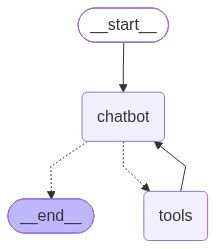

In [6]:
class State(TypedDict):
    messages: Annotated[list, add_messages]


shop_tools = [count_invoices, invoice_total, support_rep]
llm_with_tools = llm.bind_tools(shop_tools)


def chatbot_node(state: State) -> dict:
    return {'messages': [llm_with_tools.invoke(state['messages'])]}


builder = StateGraph(State)
builder.add_node('chatbot', chatbot_node)
builder.add_node('tools', ToolNode(shop_tools))
builder.add_edge(START, 'chatbot')
builder.add_conditional_edges('chatbot', tools_condition)
builder.add_edge('tools', 'chatbot')
loop = builder.compile()

show_graph(loop)


You should see `chatbot` looping through `tools` and a path to `END`. That is `Runner` from 08, with the lid off.


In [7]:
QUESTION = (
    'How many invoices does Helena Holý have, what is her total spend, '
    'and who is her support representative?'
)

loop_out = loop.invoke(
    {
        'messages': [
            {
                'role': 'system',
                'content': 'Use the tools. Do not invent numbers or names.',
            },
            {'role': 'user', 'content': QUESTION},
        ]
    }
)
print(loop_out['messages'][-1].content)


- **Invoices:** Helena Holý has **7** invoices.  
- **Total spend:** **$49.62**  
- **Support representative:** **Steve Johnson**


The last message should name **7**, **49.62**, and **Steve Johnson**. If nano skipped a tool, rerun the invoke cell after setting `llm = ChatOpenAI(model=model_strong, reasoning_effort='none')` and rebuilding `llm_with_tools` / `loop`. Do not add a forced tool choice.

### Part 3 — Pause, look, resume

08 ran to the end. A desk that sends numbers to a customer often must **stop** first.

`interrupt(...)` pauses inside a node. Resume with the **same** `thread_id` and `Command(resume=...)`. That only works if you compiled with a checkpointer (`MemorySaver` — in memory, gone when the kernel dies).

We send the finished draft to a `gate` instead of `END`. The gate asks you whether to release it.

Talking points:

1. `tools_condition` mapping: when there are no tool calls, go to `gate`, not `END`.
2. First `invoke` returns a dict with `__interrupt__`. The draft is in there. The customer has not been 'sent' anything.
3. `get_state(config)` is Observe. `next` should be the gate.
4. Second `invoke` is `Command(resume='yes')`. Same `thread_id`.


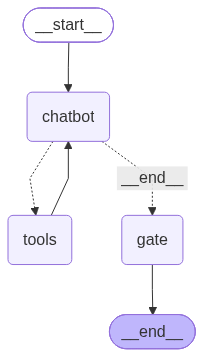

In [8]:
def gate_node(state: State) -> dict:
    draft = state['messages'][-1].content
    decision = interrupt(
        'Draft for the customer:\n'
        + str(draft)
        + '\n\nType yes to release, or type a note.'
    )
    return {'messages': [{'role': 'assistant', 'content': 'release=' + str(decision)}]}


memory = MemorySaver()
builder = StateGraph(State)
builder.add_node('chatbot', chatbot_node)
builder.add_node('tools', ToolNode(shop_tools))
builder.add_node('gate', gate_node)
builder.add_edge(START, 'chatbot')
builder.add_conditional_edges(
    'chatbot',
    tools_condition,
    {'tools': 'tools', END: 'gate'},
)
builder.add_edge('tools', 'chatbot')
builder.add_edge('gate', END)
gated = builder.compile(checkpointer=memory)

show_graph(gated)


`gate` sits on the path that used to be `END`. Compile used `checkpointer=memory`. Now invoke until it stops.


In [9]:
config = {'configurable': {'thread_id': 'helena-1'}}

paused = gated.invoke(
    {
        'messages': [
            {
                'role': 'system',
                'content': 'Use the tools. Do not invent numbers or names.',
            },
            {'role': 'user', 'content': QUESTION},
        ]
    },
    config,
)
print('keys:', list(paused.keys()) if isinstance(paused, dict) else type(paused))
print(paused)


keys: ['messages', '__interrupt__']
{'messages': [SystemMessage(content='Use the tools. Do not invent numbers or names.', additional_kwargs={}, response_metadata={}, id='2ee183a3-23fa-4d12-b432-abd93be3003e'), HumanMessage(content='How many invoices does Helena Holý have, what is her total spend, and who is her support representative?', additional_kwargs={}, response_metadata={}, id='59da80ca-cc4b-4300-8f91-89fa1deaf943'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 71, 'prompt_tokens': 207, 'total_tokens': 278, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-nano-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-

Look for `__interrupt__`. The draft is the payload. Nothing after the gate has run.

`get_state` is the official Observe.


In [10]:
snap = gated.get_state(config)
print('next:', snap.next)
print('last message:', snap.values['messages'][-1].content[:400])


next: ('gate',)
last message: Helena Holý has **7 invoices**, total spend of **$49.62**, and her support representative is **Steve Johnson**.


Resume. Same `config`. You are the human in the loop.


In [11]:
released = gated.invoke(Command(resume='yes'), config)
print(released['messages'][-1].content)


release=yes


## 3. Observe

Write these down, next to the 08 page:

| | 08 Agents SDK | 09 LangGraph |
|---|---|---|
| Who draws the arrows? | The SDK (`as_tool` / `handoff`) | You (`add_edge`) |
| Picture | `draw_graph(agent)` | `compiled.get_graph()` |
| The loop | `Runner` | `chatbot` + `tools` + `tools_condition` |
| Pause / resume | Not in 08 | `interrupt` + `Command` + `thread_id` |
| Same Helena facts? | 7 / 49.62 / Steve | should match |

If the two frameworks disagree on Helena, the tools are the source of truth — you printed them in Part 1.

LangGraph did not make the model smarter. It made the **control flow inspectable and stoppable**. CrewAI (10) will name roles instead of nodes. LlamaIndex (11) will attach the shop documents. The Chinook tools stay.


## 4. Challenge

Puja Srivastava is the other customer from 08.

Invoke the **Part 2** graph (`loop` — no gate) with the same three questions about Puja. Bind `final_text` to the last message content. The check looks for the three facts in that string.


In [ ]:
# final_text = ...


In [ ]:
import re

assert final_text, 'final_text should be the last message'
low = final_text.lower()
assert re.search(r'\b6\b', final_text), "Puja's invoice count (6) should appear as its own number"
assert '36.64' in final_text.replace(',', ''), "Puja's spend should appear"
assert 'jane' in low or 'peacock' in low, "Puja's support rep should appear"
print('final_text:', final_text)
